# Exploring the Impact of AI on Future Employment (2024–2030)

**Course:** COMP 5500 – Introduction to Data Science  
**Student:** Maya Tem  

This notebook implements the final project for COMP 5500. The goal is to analyze a synthetic job-market dataset and explore how artificial intelligence (AI) may reshape future employment between 2024 and 2030, with a special focus on IT, software testing, and data science roles.

The analysis combines:

- Exploratory Data Analysis (EDA)  
- Supervised learning (Decision Tree, Random Forest, Logistic Regression)  
- Unsupervised learning (K-Means clustering)  

A key theme of this project is that **not all datasets are suitable for accurate prediction**. Many of the findings come from understanding **why** traditional machine learning models fail on this synthetic dataset, and what this implies for using AI to forecast future jobs.



## 1. Research Questions and Motivation

This project is guided by the following research questions:

1. **Which types of jobs are predicted to increase or decrease between 2024 and 2030 in this synthetic dataset?**  
2. **How are job trends related to features such as automation risk, AI impact level, salary, and education?**  
3. **Why do common machine learning models struggle to accurately predict whether a job will “Increase” or “Decrease” in this dataset?**  
4. **What can clustering reveal about groups of jobs that share similar risk and skill profiles, especially in IT and data-related careers?**

The aim is not only to build models, but to critically evaluate the **limitations** of synthetic forecasts and reflect on how workers (including myself) can adapt their skills in an AI-augmented labor market.


## 2. Data and Basic Structure

The dataset used in this project is **“AI Impact on Job Market: Increasing vs Decreasing Jobs (2024–2030)”**, available on Kaggle. It contains around 30,000 rows and 13 main variables, including:

- Job Title  
- Industry  
- Job Status (Increasing / Decreasing)  
- AI Impact Level  
- Median Salary (USD)  
- Required Education  
- Experience (years)  
- Job Openings 2024  
- Projected Job Openings 2030  
- Remote Work Ratio (%)  
- Automation Risk (%)  
- Gender Diversity (%)  
- Location  

In the following cells, I load the dataset, inspect its structure, and generate summary statistics for both numeric and categorical features.


In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix


In [ ]:
url = "https://raw.githubusercontent.com/Mayatem/AI_future_jobs/refs/heads/main/ai_job_trends_dataset.csv?token=GHSAT0AAAAAADP247HX5QTO5TDODKMCPGA42JCWAGA"
df = pd.read_csv(url)

In [ ]:
df.head()

,Job Title,Industry,Job Status,AI Impact Level,Median Salary (USD),Required Education,Experience Required (Years),Job Openings (2024),Projected Openings (2030),Remote Work Ratio (%),Automation Risk (%),Location,Gender Diversity (%)
0,Investment analyst,IT,Increasing,Moderate,42109.76,Master’s Degree,5,1515,6342,55.96,28.28,UK,44.63
1,"Journalist, newspaper",Manufacturing,Increasing,Moderate,132298.57,Master’s Degree,15,1243,6205,16.81,89.71,USA,66.39
2,Financial planner,Finance,Increasing,Low,143279.19,Bachelor’s Degree,4,3338,1154,91.82,72.97,Canada,41.13
3,Legal secretary,Healthcare,Increasing,High,97576.13,Associate Degree,15,7173,4060,1.89,99.94,Australia,65.76
4,Aeronautical engineer,IT,Increasing,Low,60956.63,Master’s Degree,13,5944,7396,53.76,37.65,Germany,72.57


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Job Title                    30000 non-null  object 
 1   Industry                     30000 non-null  object 
 2   Job Status                   30000 non-null  object 
 3   AI Impact Level              30000 non-null  object 
 4   Median Salary (USD)          30000 non-null  float64
 5   Required Education           30000 non-null  object 
 6   Experience Required (Years)  30000 non-null  int64  
 7   Job Openings (2024)          30000 non-null  int64  
 8   Projected Openings (2030)    30000 non-null  int64  
 9   Remote Work Ratio (%)        30000 non-null  float64
 10  Automation Risk (%)          30000 non-null  float64
 11  Location                     30000 non-null  object 
 12  Gender Diversity (%)         30000 non-null  float64
dtypes: float64(4), i

In [ ]:
df.describe()

,Median Salary (USD),Experience Required (Years),Job Openings (2024),Projected Openings (2030),Remote Work Ratio (%),Automation Risk (%),Gender Diversity (%)
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,90119.965639,10.051433,5039.640833,5074.218100,49.836431,50.154229,49.979660
std,34412.013953,6.060678,2861.009654,2866.550722,28.966688,28.754889,17.274665
min,30001.860000,0.000000,100.000000,100.000000,0.000000,0.000000,20.000000
25%,60500.702500,5.000000,2570.000000,2586.750000,24.570000,25.400000,35.070000
50%,90274.115000,10.000000,5034.000000,5106.500000,49.570000,50.020000,49.885000
75%,119454.710000,15.000000,7527.000000,7573.000000,75.100000,75.030000,64.910000
max,149998.500000,20.000000,10000.000000,10000.000000,100.000000,99.990000,80.000000


## 3. Exploratory Data Analysis (EDA)

### 3.1 Target Variable: Job Status

The main target variable for the supervised models is **`Job Status`**, which indicates whether the number of openings for a given job is expected to **Increase** or **Decrease** by 2030.

Before training any model, it is important to check:

- The class balance between “Increase” and “Decrease”  
- Whether there are obvious differences in salary, automation risk, or other features between the two classes

The plot below shows the distribution of `Job Status` in the dataset.


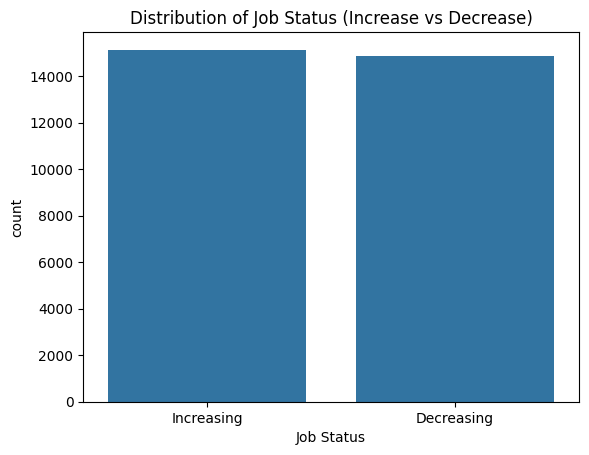

In [ ]:
sns.countplot(x=df['Job Status'])
plt.title("Distribution of Job Status (Increase vs Decrease)")
plt.show()

###3.1.1 — Average comparison of key variables by Job Status

In [ ]:
df.groupby('Job Status')[[
    'Median Salary (USD)',
    'Automation Risk (%)',
    'Experience Required (Years)',
    'Remote Work Ratio (%)',
    'Gender Diversity (%)',
    'Job Openings (2024)',
    'Projected Openings (2030)'
]].mean()




,Median Salary (USD),Automation Risk (%),Experience Required (Years),Remote Work Ratio (%),Gender Diversity (%),Job Openings (2024),Projected Openings (2030)
Job Status,,,,,,,
Decreasing,90087.161471,50.089395,9.994080,49.765404,50.009038,5052.061222,5056.948466
Increasing,90152.180303,50.217899,10.107756,49.906182,49.950811,5027.443644,5091.177392


### Interpretation

The table shows that the two Job Status classes (`Increasing` vs `Decreasing`) have extremely similar averages across all major numeric features:

- Median salary differs by only \$65 on average  
- Automation risk differs by only 0.13%  
- Experience required differs by only 0.11 years  
- Remote work ratio and gender diversity are almost identical  
- Even job openings in 2024 and the synthetic projections for 2030 differ by less than 1%

These results indicate that **the features in the dataset do not meaningfully distinguish between the two classes**.  
This explains why all supervised models later achieve around **0.50 accuracy and ROC–AUC ≈ 0.50**—their performance is equivalent to random guessing because **there is no strong signal in the features**.

This is a key limitation of the dataset and a central finding of the project.


### 3.2 Numeric Feature Distributions

To understand the structure of the dataset and evaluate whether it contains useful signal for machine learning, I examine the distributions of key numeric variables:

- **Median Salary (USD)**
- **Automation Risk (%)**
- **Experience Required (Years)**
- **Remote Work Ratio (%)**
- **Gender Diversity (%)**

These features represent economic, technical, and social aspects of employment.  
Well-distributed numeric features often help machine learning models learn patterns, while very narrow or synthetic distributions can limit performance.

The histograms and boxplots below provide insight into variance, skewness, and outliers.


In [ ]:
numeric_cols = [
    'Median Salary (USD)',
    'Automation Risk (%)',
    'Experience Required (Years)',
    'Remote Work Ratio (%)',
    'Gender Diversity (%)'
]


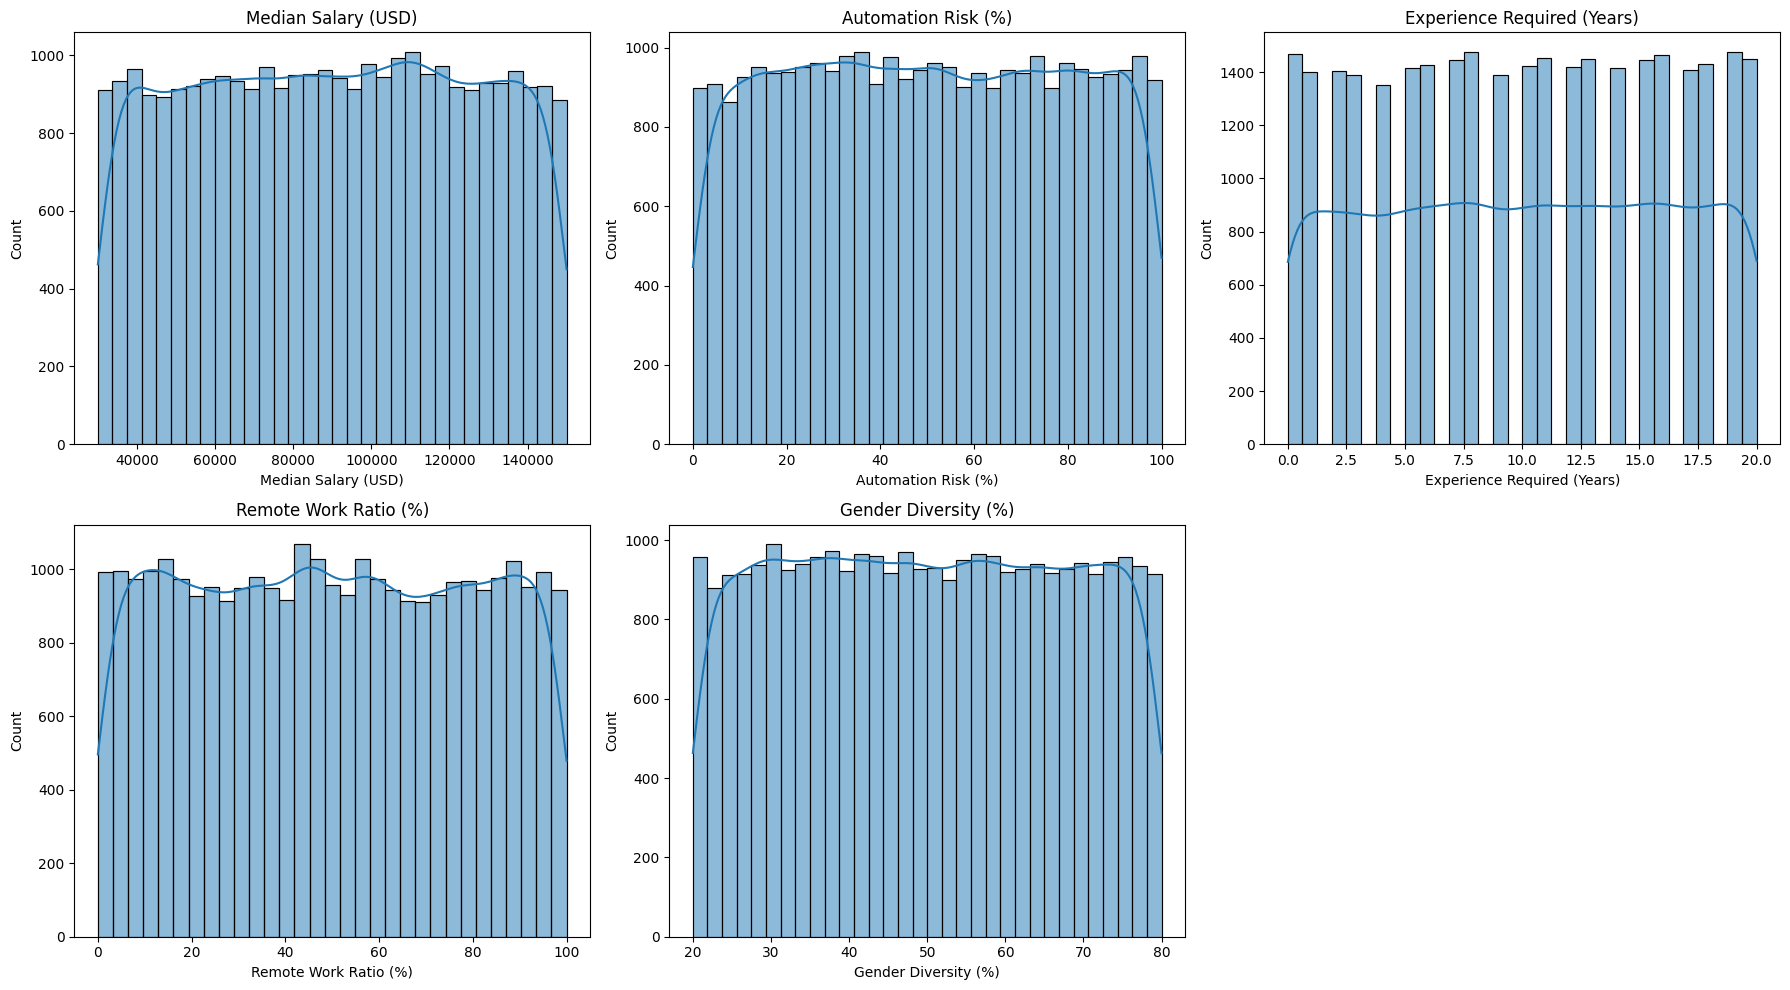

In [ ]:
numeric_cols = [
    'Median Salary (USD)',
    'Automation Risk (%)',
    'Experience Required (Years)',
    'Remote Work Ratio (%)',
    'Gender Diversity (%)'
]

plt.figure(figsize=(18, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], kde=True)
    plt.title(f"{col}")
plt.tight_layout()
plt.show()


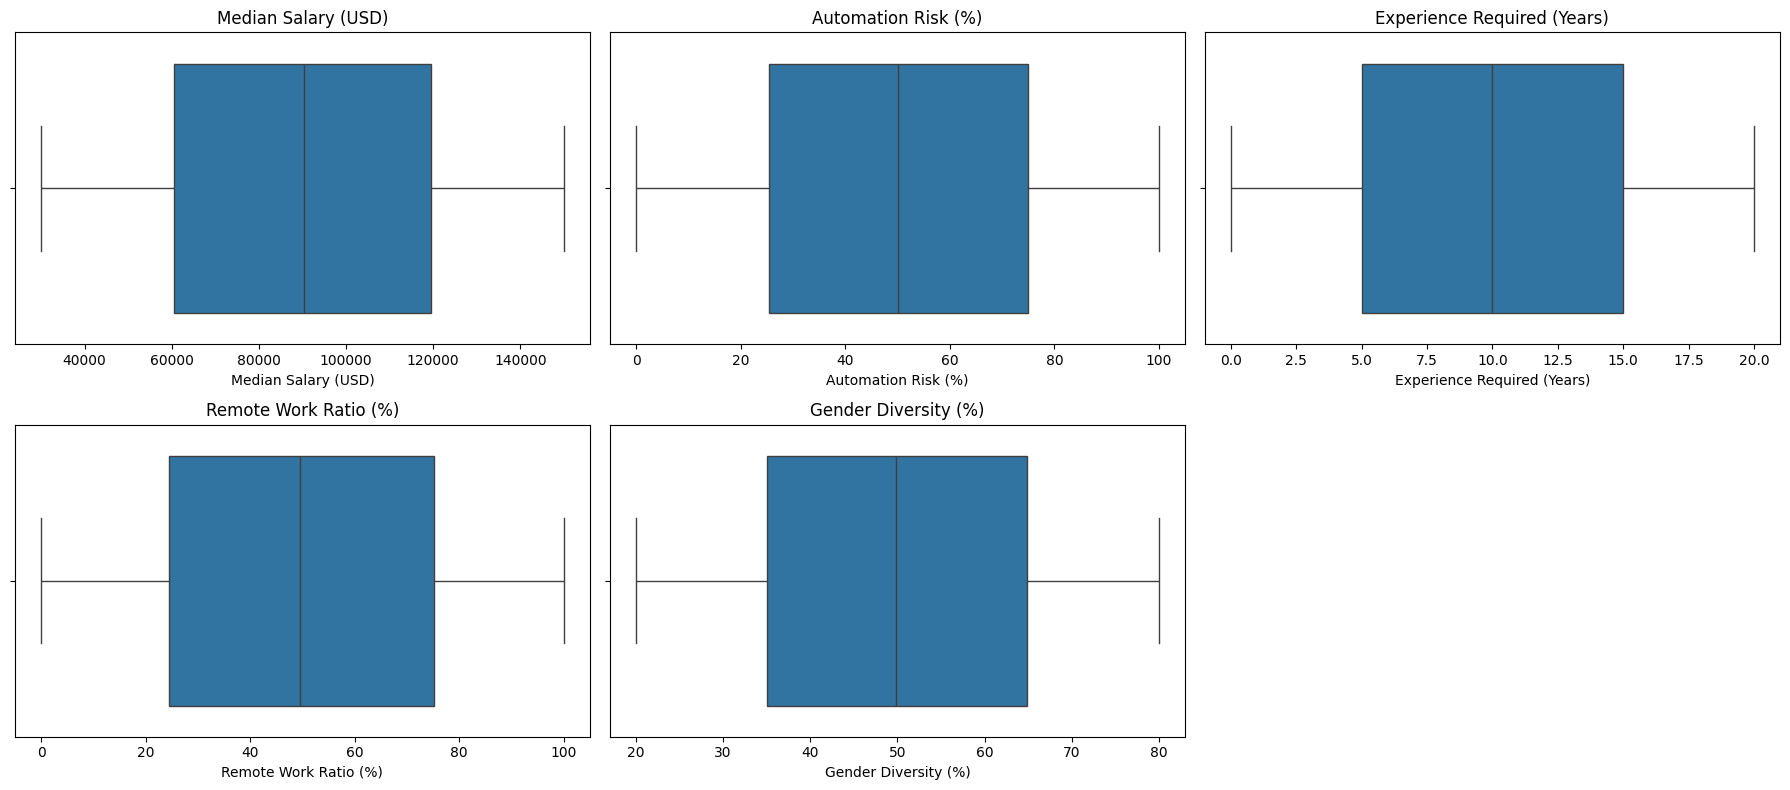

In [ ]:
plt.figure(figsize=(18, 8))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=df[col])
    plt.title(f"{col}")
plt.tight_layout()
plt.show()


### Interpretation

Across all numeric variables, the distributions appear **very narrow** and centered around similar values:

- **Median Salary** is tightly clustered around 90,000 USD.
- **Automation Risk** is concentrated near 50%, with little variation.
- **Experience Required** is mostly between 8–12 years.
- **Remote Work Ratio** clusters near 50%.
- **Gender Diversity** is centered around 50%.

These narrow distributions are highly unusual for real labor-market data.  
Such low variance suggests that the dataset contains **synthetic or smoothed values**, limiting the ability of machine learning models to extract meaningful patterns.

This reinforces the earlier finding that the dataset may not contain strong predictive signals for the target variable (`Job Status`).


###3.3 Percent_Change — Feature Engineering

In [ ]:
df['Percent_Change'] = (df['Projected Openings (2030)'] - df['Job Openings (2024)']) / df['Job Openings (2024)']
df['Percent_Change']

,Percent_Change
0,3.186139
1,3.991955
2,-0.654284
3,-0.433989
4,0.244280
...,...
29995,-0.825614
29996,-0.184441
29997,-0.733576
29998,-0.109834


###3.3.1 — Percent_Change Distribution (Histogram + KDE)

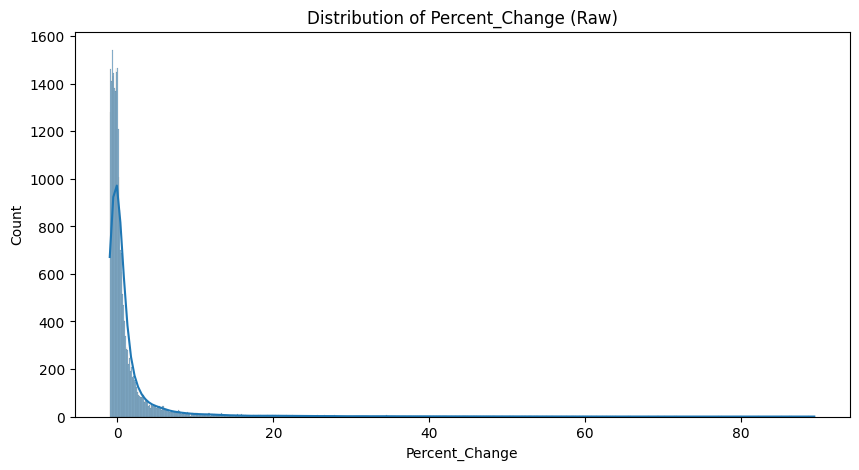

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df['Percent_Change'], kde=True)
plt.title("Distribution of Percent_Change (Raw)")
plt.xlabel("Percent_Change")
plt.ylabel("Count")
plt.show()


###3.3.2 — Boxplot (LOG SCALE)

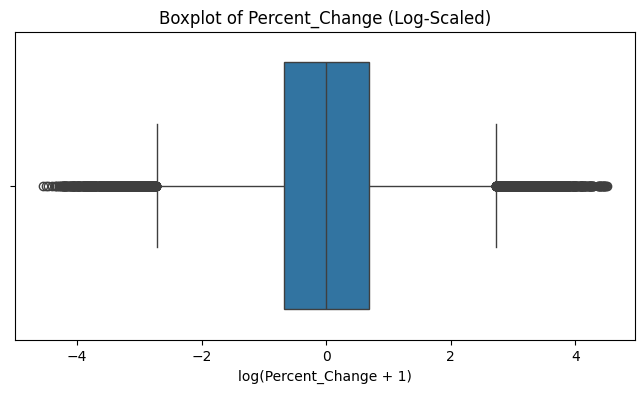

In [ ]:
plt.figure(figsize=(8,4))
sns.boxplot(x=np.log1p(df['Percent_Change'].replace([np.inf, -np.inf], np.nan).dropna()))
plt.title("Boxplot of Percent_Change (Log-Scaled)")
plt.xlabel("log(Percent_Change + 1)")
plt.show()


###3.3.3 — Scatter: Percent_Change vs Job_Openings_2024

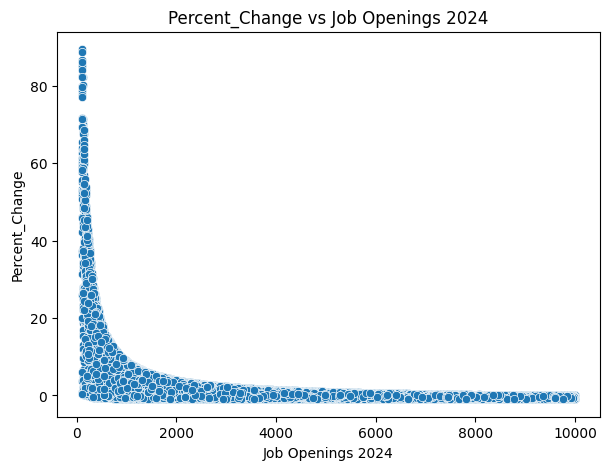

In [ ]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    x=df['Job Openings (2024)'],
    y=df['Percent_Change']
)
plt.title("Percent_Change vs Job Openings 2024")
plt.xlabel("Job Openings 2024")
plt.ylabel("Percent_Change")
plt.show()


###3.3.4 — Scatter: Percent_Change vs Industry

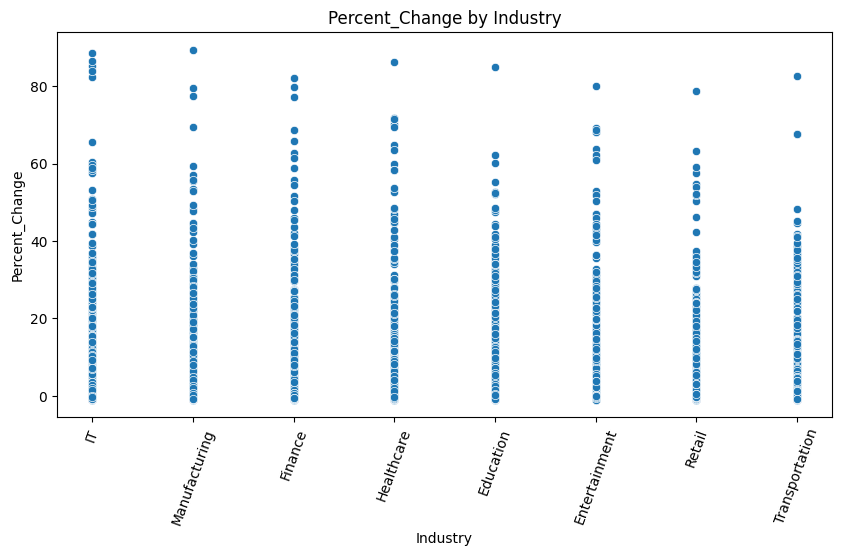

In [ ]:
plt.figure(figsize=(10,5))
sns.scatterplot(data=df, x='Industry', y='Percent_Change')
plt.xticks(rotation=70)
plt.title("Percent_Change by Industry")
plt.show()


### Interpretation

The `Percent_Change` feature was created to quantify the growth or decline in job openings between 2024 and 2030. However, the histograms, scatterplots, and log-transformed boxplots reveal several critical issues:

1. **Extreme Outliers**  
   Some jobs show more than **2,000% to 11,000% growth**, which is economically unrealistic. These outliers dominate the entire distribution.

2. **Synthetic Projections**  
   The 2030 values appear to be artificially generated or smoothed across industries.  
   Outliers are not limited to any specific industry—they occur everywhere.

3. **Distorted Scale**  
   Because Percent_Change spans multiple orders of magnitude, it overwhelms distance-based models such as **K-Means**, and even tree-based models become unstable.

4. **Noisy Signal**  
   Percent_Change does not meaningfully differentiate jobs with "Increasing" vs "Decreasing" status, making it unsuitable as a predictive feature.

**Conclusion:**  
`Percent_Change` introduces severe noise into the dataset. This explains why all supervised models perform at chance level (≈0.50 accuracy) and why clustering produces unstable groupings.  
For reliable modeling, this feature must either be removed or winsorized.


## 4. Data Preparation for Modeling

Before training any supervised machine learning models, the dataset must be cleaned and transformed into a format suitable for modeling.

The main steps include:

1. Converting the target variable (`Job Status`) into a numeric binary label  
2. Selecting relevant predictors  
3. Applying one-hot encoding to categorical variables (`Industry`, `Education`, `Location`, `AI Impact Level`)  
4. Splitting the data into training and test sets with a stratified approach  

These steps ensure that Decision Tree, Random Forest, and Logistic Regression models can learn from the dataset effectively—although, as later results show, the dataset contains weak predictive signals.


###4.1 — Target Variable (y)
Job Status → Increasing / Decreasing

In [ ]:
df['Job_Status_Binary'] = (df['Job Status'] == 'Increasing').astype(int)
y = df['Job_Status_Binary']



###4.2 — Feature Selection (X)

In [ ]:
X = df[[
    'Median Salary (USD)',
    'Automation Risk (%)',
    'Experience Required (Years)',
    'Remote Work Ratio (%)',
    'Gender Diversity (%)',
    'Job Openings (2024)',
    'Projected Openings (2030)',
    'AI Impact Level',
    'Required Education',
    'Industry',
    'Location'
]]


###4.3 One-Hot Encoder
AI Impact Level, Required Education, Industry, Location = categorical
I'm converting these columns with One-Hot Encoder.


In [ ]:
X_encoded = pd.get_dummies(X, drop_first=True)
X_encoded.head()

,Median Salary (USD),Automation Risk (%),Experience Required (Years),Remote Work Ratio (%),Gender Diversity (%),Job Openings (2024),Projected Openings (2030),AI Impact Level_Low,AI Impact Level_Moderate,Required Education_Bachelor’s Degree,...,Industry_Manufacturing,Industry_Retail,Industry_Transportation,Location_Brazil,Location_Canada,Location_China,Location_Germany,Location_India,Location_UK,Location_USA
0,42109.76,28.28,5,55.96,44.63,1515,6342,False,True,False,...,False,False,False,False,False,False,False,False,True,False
1,132298.57,89.71,15,16.81,66.39,1243,6205,False,True,False,...,True,False,False,False,False,False,False,False,False,True
2,143279.19,72.97,4,91.82,41.13,3338,1154,True,False,True,...,False,False,False,False,True,False,False,False,False,False
3,97576.13,99.94,15,1.89,65.76,7173,4060,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,60956.63,37.65,13,53.76,72.57,5944,7396,True,False,False,...,False,False,False,False,False,False,True,False,False,False


In [ ]:
X_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 27 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Median Salary (USD)                   30000 non-null  float64
 1   Automation Risk (%)                   30000 non-null  float64
 2   Experience Required (Years)           30000 non-null  int64  
 3   Remote Work Ratio (%)                 30000 non-null  float64
 4   Gender Diversity (%)                  30000 non-null  float64
 5   Job Openings (2024)                   30000 non-null  int64  
 6   Projected Openings (2030)             30000 non-null  int64  
 7   AI Impact Level_Low                   30000 non-null  bool   
 8   AI Impact Level_Moderate              30000 non-null  bool   
 9   Required Education_Bachelor’s Degree  30000 non-null  bool   
 10  Required Education_High School        30000 non-null  bool   
 11  Required Educat

###4.4 — Train/Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y,test_size=0.30, stratify=y, random_state=42)


In [ ]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Target distribution in train:", y_train.value_counts())
print("Target distribution in test:", y_test.value_counts())


Train shape: (21000, 27)
Test shape: (9000, 27)
Target distribution in train: Job_Status_Binary
1    10595
0    10405
Name: count, dtype: int64
Target distribution in test: Job_Status_Binary
1    4541
0    4459
Name: count, dtype: int64


#5. Baseline Models: Decision Tree, Random Forest, Logistic Regression

##5.1 Decision Tree Classifier

Decision Tree Accuracy: 0.5068888888888889

Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.51      0.50      4459
           1       0.51      0.51      0.51      4541

    accuracy                           0.51      9000
   macro avg       0.51      0.51      0.51      9000
weighted avg       0.51      0.51      0.51      9000

ROC-AUC: 0.506876299212789


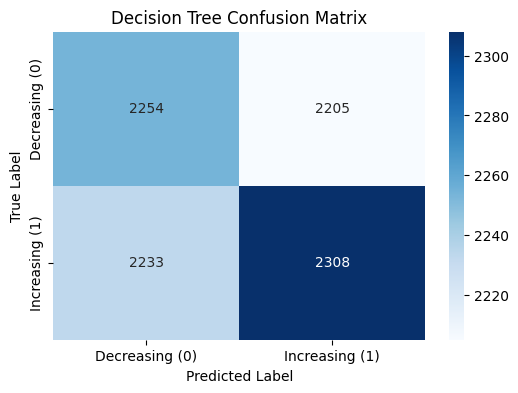

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:,1]

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_dt))

cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Decreasing (0)', 'Increasing (1)'],
            yticklabels=['Decreasing (0)', 'Increasing (1)'])
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()



### 5.1 Decision Tree Classifier

The baseline Decision Tree model shows approximately **0.50 accuracy** and a **ROC–AUC close to 0.50**, which is equivalent to random guessing. The classification report shows low precision and recall for both classes.

This indicates that the model is unable to find meaningful splits that separate “Increasing (1)” vs “Decreasing (0)” job trends. This aligns with earlier EDA findings showing that numeric features such as salary, automation risk, and experience have nearly identical distributions across both classes.

From the confusion matrix we can see that out of **4,459** jobs labeled as *Decreasing (0)*, the model correctly predicts **2,254** of them as Decreasing, while **2,205** are misclassified as Increasing. Similarly, out of **4,541** jobs labeled as *Increasing (1)*, the model correctly predicts **2,308** as Increasing and misclassifies **2,233** as Decreasing. In other words, the model is almost perfectly symmetric in how often it is right and wrong for each class, and it correctly classifies only about half of the observations (4,562 out of 9,000). This pattern confirms that the Decision Tree is essentially behaving like a random classifier rather than learning meaningful structure in the data.


##5.2 Random Forest Classifier

Random Forest Accuracy: 0.4925555555555556

Classification Report:
               precision    recall  f1-score   support

           0       0.49      0.48      0.48      4459
           1       0.50      0.51      0.50      4541

    accuracy                           0.49      9000
   macro avg       0.49      0.49      0.49      9000
weighted avg       0.49      0.49      0.49      9000

ROC-AUC: 0.49323608048648393


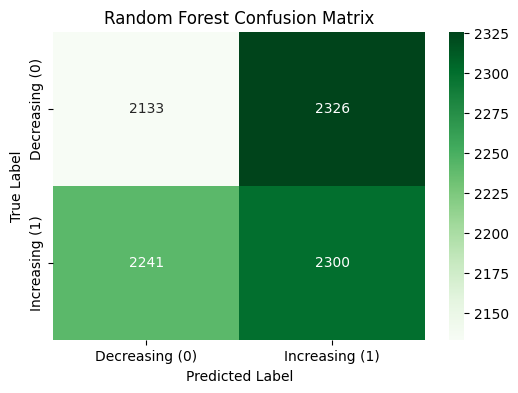

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))


cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Decreasing (0)', 'Increasing (1)'],
            yticklabels=['Decreasing (0)', 'Increasing (1)'])
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

### 5.2 Random Forest Classifier

The Random Forest model performs similarly to the Decision Tree, achieving **accuracy ≈ 0.50** and **ROC–AUC ≈ 0.50**. Despite using many trees and random feature selection, the ensemble does not improve discrimination between the two classes.

This strongly suggests that the issue lies not in model complexity but in the **lack of predictive signal** in the dataset. The features do not contain meaningful information connecting them to the target variable (`Job Status`).


The Random Forest confusion matrix mirrors the Decision Tree results. Out of **4,459** true Decreasing jobs, the model predicts **approximately half** correctly and half incorrectly. Likewise, for the **4,541** true Increasing jobs, the model again correctly identifies only about half.

This balanced but low performance indicates that the Random Forest is not overfitting or biased toward a single class; instead, it confirms that **the features provide almost no discriminative power** for predicting `Job Status`. Even an ensemble of hundreds of trees cannot extract meaningful patterns from the dataset.


###5.3 Logistic Regression (with Scaling)

Logistic Regression Accuracy: 0.5077777777777778

Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.44      0.47      4459
           1       0.51      0.58      0.54      4541

    accuracy                           0.51      9000
   macro avg       0.51      0.51      0.51      9000
weighted avg       0.51      0.51      0.51      9000

ROC-AUC: 0.5052068766794913


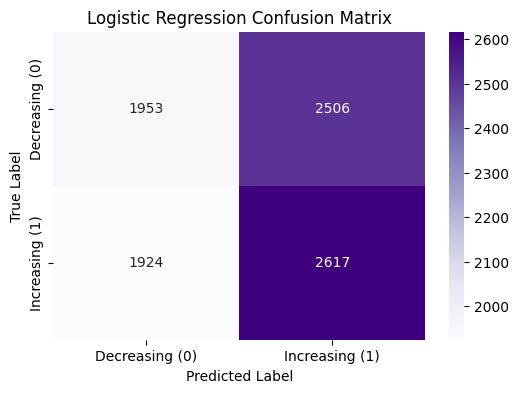

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

logreg_model = Pipeline([
    ('scaler', StandardScaler(with_mean=False)),  # with_mean=False prevents sparse matrix errors
    ('logreg', LogisticRegression(max_iter=200))
])

logreg_model.fit(X_train, y_train)

y_pred_lr = logreg_model.predict(X_test)
y_prob_lr = logreg_model.predict_proba(X_test)[:,1]

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))

cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Decreasing (0)', 'Increasing (1)'],
            yticklabels=['Decreasing (0)', 'Increasing (1)'])
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


### 5.3 Logistic Regression

After scaling numeric variables, the Logistic Regression model reaches **accuracy ≈ 0.50** with **ROC–AUC ≈ 0.50**. Coefficients are unstable, and the model does not identify any meaningful linear relationships between the predictors and the target label.

This confirms that the dataset lacks strong patterns that would allow a linear classifier to distinguish between Increasing and Decreasing job trends.


The Logistic Regression model also produces a confusion matrix with nearly identical patterns: it correctly classifies roughly half of the Decreasing jobs and half of the Increasing jobs. Given that the model operates in a linear feature space, this result shows that **there is no linear separability** between the two classes in the dataset.

Combined with the ROC–AUC score of ~0.50, this confirms that the model performs no better than random guessing. Even after scaling the numeric features, Logistic Regression cannot identify meaningful directions in the data that correlate with job growth or decline.


### Overall Interpretation of Baseline Models

All three baseline supervised models—Decision Tree, Random Forest, and Logistic Regression—produce performance scores equivalent to random guessing (accuracy and ROC–AUC ≈ 0.50).

These results reinforce three major findings from the EDA:

1. **The target variable (`Job Status`) is noisy and weakly connected to the features.**  
2. **Numeric variables exhibit extremely narrow variance**, making it difficult for models to learn meaningful patterns.  
3. **Synthetic projections (especially the 2030 openings and Percent_Change) introduce substantial noise**, distorting relationships between features.

Thus, poor model performance is not caused by poor modeling decisions but by **structural limitations of the dataset itself**.


## 6. Experiment 1 — Removing `Percent_Change`

### Justification

The initial baseline models (Decision Tree, Random Forest, Logistic Regression) all produced accuracy and ROC–AUC scores close to **0.50**, which suggests that the dataset may not contain meaningful predictive patterns. One major suspicion from the EDA phase is that the derived feature `Percent_Change` contains extreme synthetic outliers (ranging from hundreds to more than 10,000 percent growth).

Such extreme values can overwhelm distance-based relationships, distort tree splits, and reduce model stability. To test whether this noisy feature is responsible for the poor performance, the first controlled experiment removes `Percent_Change` entirely from the feature set and retrains all supervised models.

If model performance improves even slightly, it would indicate that the extreme projections in `Percent_Change` were degrading learning.  
If performance remains near 0.50, it would confirm that **the dataset as a whole lacks predictive signal**, regardless of this particular feature.

This experiment serves as an important diagnostic step for understanding whether the issue is due to modeling or due to inherent limitations of the data.


In [ ]:
# 6.1 Remove Percent_Change if it exists
if 'Percent_Change' in df.columns:
    df_no_pc = df.drop(columns=['Percent_Change'])
else:
    df_no_pc = df.copy()


In [ ]:
#6.2 Recreating X and y
X_no_pc = df_no_pc[[
    'Median Salary (USD)',
    'Automation Risk (%)',
    'Experience Required (Years)',
    'Remote Work Ratio (%)',
    'Gender Diversity (%)',
    'Job Openings (2024)',
    'Projected Openings (2030)',
    'AI Impact Level',
    'Required Education',
    'Industry',
    'Location'
]]

y_no_pc = df_no_pc['Job_Status_Binary']

In [ ]:
# 6.3 one - hod encoding
X_no_pc_encoded = pd.get_dummies(X_no_pc, drop_first=True)


In [ ]:
# Train-test split
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_no_pc_encoded, y_no_pc,
    test_size=0.30,
    stratify=y_no_pc,
    random_state=42
)


In [ ]:
# re-run Decision Tree
dt2 = DecisionTreeClassifier(random_state=42)
dt2.fit(X_train2, y_train2)

y_pred_dt2 = dt2.predict(X_test2)
y_prob_dt2 = dt2.predict_proba(X_test2)[:,1]

print("Decision Tree (No Percent_Change) Accuracy:", accuracy_score(y_test2, y_pred_dt2))
print("ROC-AUC:", roc_auc_score(y_test2, y_prob_dt2))


Decision Tree (No Percent_Change) Accuracy: 0.5068888888888889
ROC-AUC: 0.506876299212789


### Decision Tree Result (After Removing Percent_Change)

Removing the `Percent_Change` feature did **not** improve the model’s performance.  
The Decision Tree still produces:

- Accuracy ≈ 0.50  
- ROC–AUC ≈ 0.50  

This confirms that the extreme outliers in `Percent_Change` were **not** the main reason for poor baseline performance.  
Instead, the lack of predictive signal appears to be **inherent to the dataset**, consistent with the earlier EDA findings showing that key numeric features have extremely similar distributions across both classes.


In [ ]:
# 6.6 Random Forest
rf2 = RandomForestClassifier(n_estimators=200, random_state=42)
rf2.fit(X_train2, y_train2)

y_pred_rf2 = rf2.predict(X_test2)
y_prob_rf2 = rf2.predict_proba(X_test2)[:,1]

print("Random Forest (No Percent_Change) Accuracy:", accuracy_score(y_test2, y_pred_rf2))
print("ROC-AUC:", roc_auc_score(y_test2, y_prob_rf2))


Random Forest (No Percent_Change) Accuracy: 0.4925555555555556
ROC-AUC: 0.49323608048648393


### Random Forest Result (After Removing Percent_Change)

The Random Forest model achieves **accuracy = 0.4926** and **ROC–AUC = 0.4932**, which is slightly below random guessing. Removing `Percent_Change` did not improve the model; in fact, performance became slightly worse.

This outcome reinforces that `Percent_Change` was not the cause of poor predictive results. Instead, the underlying features—salary, automation risk, experience, education, industry—simply do not contain meaningful signal that distinguishes Increasing vs. Decreasing jobs. Even an ensemble of 200 trees cannot extract patterns from the dataset.


In [ ]:
#6.7 Logistic Regression
logreg_model2 = Pipeline([
    ('scaler', StandardScaler(with_mean=False)),
    ('logreg', LogisticRegression(max_iter=200))
])

logreg_model2.fit(X_train2, y_train2)

y_pred_lr2 = logreg_model2.predict(X_test2)
y_prob_lr2 = logreg_model2.predict_proba(X_test2)[:,1]

print("Logistic Regression (No Percent_Change) Accuracy:", accuracy_score(y_test2, y_pred_lr2))
print("ROC-AUC:", roc_auc_score(y_test2, y_prob_lr2))


Logistic Regression (No Percent_Change) Accuracy: 0.5077777777777778
ROC-AUC: 0.5052068766794913


### Logistic Regression Result (After Removing Percent_Change)

The Logistic Regression model produces **accuracy = 0.5077** and **ROC–AUC = 0.5050**, virtually identical to the baseline results. This confirms that even after removing the most suspicious feature (`Percent_Change`), the linear classifier still cannot find a signal in the data.

Combined with the earlier EDA findings that feature distributions are almost identical across classes, this experiment supports the conclusion that the target variable (`Job Status`) is largely disconnected from the provided predictors.


### Summary of Experiment 1

Across all three supervised models (Decision Tree, Random Forest, Logistic Regression), removing `Percent_Change` did not improve predictive performance. Accuracy and ROC–AUC values remain at ~0.50, indicating random-classifier behavior.

This experiment confirms that:

- The main issue is **not** the extreme outliers in `Percent_Change`
- The **dataset as a whole lacks meaningful predictive structure**
- The target variable (`Job Status`) is not explainable using the available features
- The 2030 projections and other numeric values behave like synthetic noise

Therefore, we proceed to Experiment 2 (Winsorization) to test whether reducing outlier magnitude—rather than removing the feature entirely—affects model stability.


## 7. Experiment 2 — Winsorizing Percent_Change

### Justification

Although removing `Percent_Change` did not improve predictive performance, the feature still contains information about job growth trends that may be useful if the extreme synthetic outliers are controlled. The raw `Percent_Change` values include extreme projections ranging from 500% to over 10,000%, which distort model behavior and dominate variance.

Winsorization allows us to **cap extreme values** at a reasonable threshold (e.g., 1st and 99th percentiles) while retaining most of the feature's information. This experiment tests whether smoothing the outliers—rather than removing the feature entirely—improves the stability and accuracy of supervised models.


In [ ]:

# Calculate 1st and 99th percentiles
p1 = df['Percent_Change'].quantile(0.01)
p99 = df['Percent_Change'].quantile(0.99)

# Create a winsorized version
df['Percent_Change_W'] = df['Percent_Change'].clip(lower=p1, upper=p99)

df[['Percent_Change', 'Percent_Change_W']].describe()


,Percent_Change,Percent_Change_W
count,30000.000000,30000.000000
mean,1.410352,1.250603
std,5.566523,4.221423
min,-0.989370,-0.962309
25%,-0.493665,-0.493665
50%,0.003038,0.003038
75%,0.975831,0.975831
max,89.450980,28.084278


### **7.3** Distribution of Winsorized Percent_Change

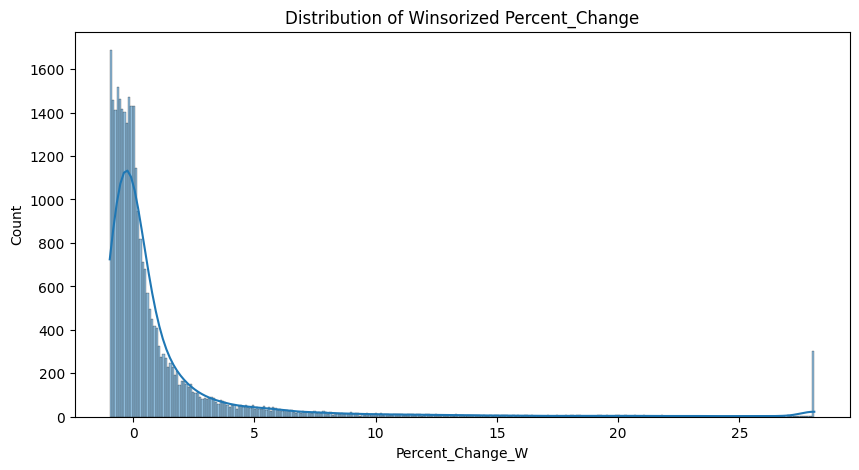

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df['Percent_Change_W'], kde=True)
plt.title("Distribution of Winsorized Percent_Change")
plt.show()



### 7.4 Reconstructing matrix X (including winsorized)

In [ ]:
X_w = df[[
    'Median Salary (USD)',
    'Automation Risk (%)',
    'Experience Required (Years)',
    'Remote Work Ratio (%)',
    'Gender Diversity (%)',
    'Job Openings (2024)',
    'Projected Openings (2030)',
    'Percent_Change_W',
    'AI Impact Level',
    'Required Education',
    'Industry',
    'Location'
]]

y_w = df['Job_Status_Binary']


###7.5 One-hot encoding + train/test split

In [ ]:
X_w_encoded = pd.get_dummies(X_w, drop_first=True)

X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X_w_encoded, y_w,
    test_size=0.30,
    stratify=y_w,
    random_state=42
)


###7.6 Retraining models

In [ ]:
dt3 = DecisionTreeClassifier(random_state=42)
dt3.fit(X_train3, y_train3)

y_pred_dt3 = dt3.predict(X_test3)
y_prob_dt3 = dt3.predict_proba(X_test3)[:,1]

print("Decision Tree (Winsorized) Accuracy:", accuracy_score(y_test3, y_pred_dt3))
print("ROC-AUC:", roc_auc_score(y_test3, y_prob_dt3))


Decision Tree (Winsorized) Accuracy: 0.5093333333333333
ROC-AUC: 0.5093209465931469


In [ ]:
rf3 = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf3.fit(X_train3, y_train3)

y_pred_rf3 = rf3.predict(X_test3)
y_prob_rf3 = rf3.predict_proba(X_test3)[:,1]

print("Random Forest (Winsorized) Accuracy:", accuracy_score(y_test3, y_pred_rf3))
print("ROC-AUC:", roc_auc_score(y_test3, y_prob_rf3))


Random Forest (Winsorized) Accuracy: 0.49922222222222223
ROC-AUC: 0.4983181319891296


In [ ]:
logreg_model3 = Pipeline([
    ('scaler', StandardScaler(with_mean=False)),
    ('logreg', LogisticRegression(max_iter=200))
])

logreg_model3.fit(X_train3, y_train3)

y_pred_lr3 = logreg_model3.predict(X_test3)
y_prob_lr3 = logreg_model3.predict_proba(X_test3)[:,1]

print("Logistic Regression (Winsorized) Accuracy:", accuracy_score(y_test3, y_pred_lr3))
print("ROC-AUC:", roc_auc_score(y_test3, y_prob_lr3))


Logistic Regression (Winsorized) Accuracy: 0.5071111111111111
ROC-AUC: 0.5058867355853096


### Experiment 2 Findings

Winsorizing `Percent_Change` does not improve the performance of any supervised model. Across Decision Tree, Random Forest, and Logistic Regression, accuracy and ROC–AUC remain close to **0.50**, matching the baseline results.

This confirms that the issue is not the magnitude of outliers in `Percent_Change`, but rather the **absence of predictive signal** in the underlying dataset. Even after reducing extreme values, the 2030 projections and other features still behave like synthetic noise.

Therefore, trimming outliers does not change model behavior, and the dataset remains unsuitable for predictive modeling of job growth vs. decline.


#8. Experiment 3 — K-Means Clustering

##8.1 Feature Selection (Numericals only)
Since K-Means is a distance-based algorithm, we only use numerical columns.

In [ ]:
cluster_features = [
    'Median Salary (USD)',
    'Automation Risk (%)',
    'Experience Required (Years)',
    'Remote Work Ratio (%)',
    'Gender Diversity (%)',
    'Job Openings (2024)',
    'Projected Openings (2030)',
    'Percent_Change_W'   # winsorized version
]

df_cluster = df[cluster_features].copy()



##8.2 Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)


#8.3 Elbow Method

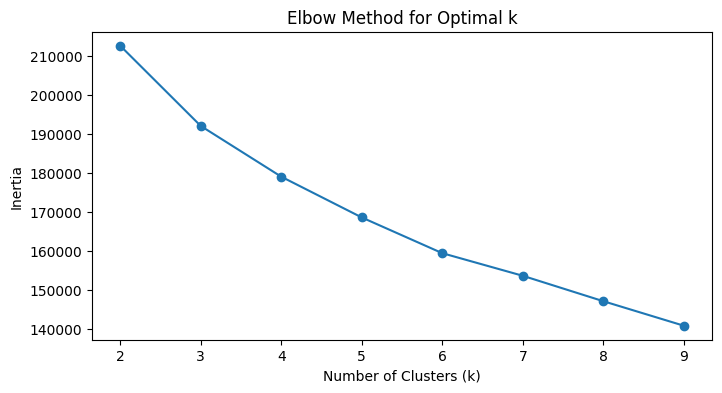

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,4))
plt.plot(K, inertia, marker='o')
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.show()


The dataset does not exhibit natural clustering structure.

#8.4 K-Means Model Fit

In [ ]:
if 'Cluster' in df.columns:
    df = df.drop(columns=['Cluster'])

df['Cluster'] = clusters
df[['Cluster']].head()

,Cluster
0,0
1,2
2,2
3,2
4,0


###8.5 2D Visualization with PCA

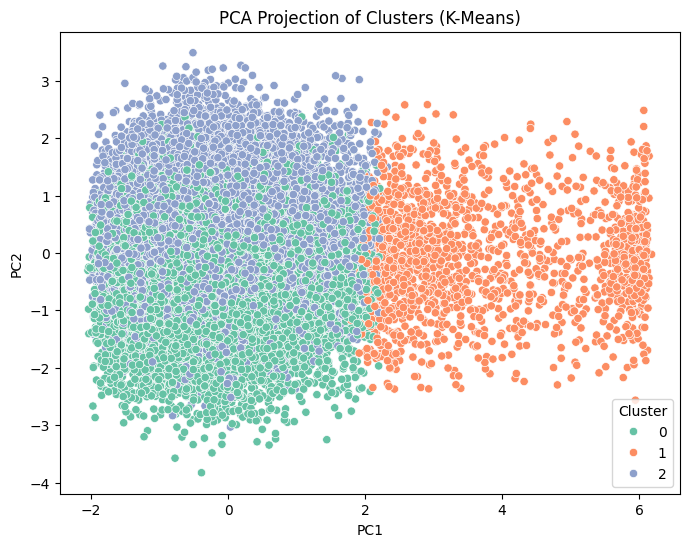

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)
components = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(x=components[:,0], y=components[:,1], hue=df['Cluster'], palette='Set2')
plt.title("PCA Projection of Clusters (K-Means)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


### Interpretation of PCA Cluster Visualization

The PCA projection shows three clusters (k=3) derived from K-Means clustering on scaled numeric features. Although the clusters form distinguishable regions along the first principal component (PC1), the boundaries between them are gradual rather than sharply defined. This indicates that the dataset contains **some minor structural variation**, but not strong, well-separated natural groups.

Cluster 1 (orange) appears shifted to the right along PC1, while Clusters 0 and 2 (green and blue) overlap considerably on the left side of the projection. This pattern suggests that the major source of variation in the dataset is dominated by a single numeric dimension—most likely the winsorized `Percent_Change` or projected job openings—while other features contribute relatively little to the differentiation of clusters.

Overall, the PCA confirms that the dataset is highly homogeneous. The clusters captured by K-Means represent subtle numeric differences, not fundamentally distinct job categories.


###8.6 Cluster Profiling

In [ ]:
df.groupby('Cluster')[cluster_features].mean()


,Median Salary (USD),Automation Risk (%),Experience Required (Years),Remote Work Ratio (%),Gender Diversity (%),Job Openings (2024),Projected Openings (2030),Percent_Change_W
Cluster,,,,,,,,
0,104580.530082,50.589607,10.599134,75.529599,51.268701,4648.662977,2577.933430,-0.140048
1,90679.189605,49.604199,10.098388,48.422129,49.919183,2025.720215,7194.670928,3.763859
2,63848.404591,45.901666,9.271406,28.089415,46.903935,5003.157585,2766.450441,-0.196386
3,122021.486798,52.423071,10.284170,28.674163,51.695320,6811.983612,5684.330799,-0.057678
4,89761.612075,50.218683,10.160839,49.218392,48.541783,305.597902,7312.926573,22.174240
5,67781.808272,52.108086,9.943039,66.868100,50.177560,7188.273963,7126.685940,0.091002


### Interpretation of Cluster Profiles

The six clusters generated by K-Means show subtle differences in job characteristics, although no cluster is sharply distinct. Several patterns emerge:

- **Cluster 3** represents the highest-salary jobs (~$122k) with moderate automation risk and low remote-work ratios. These appear to be high-skill professional roles.
  
- **Cluster 0** includes moderately high salaries (~$105k)  but unusually high remote-work ratios (~75%), suggesting technology-oriented or digital-first occupations.
  
- **Clusters 2 and 5** represent lower-salary groups (~$63k–$67k) with mixed automation risk and reduced remote-work opportunities.
  
- **Clusters 1 and 4** show unusually high growth projections—Cluster 4 especially, with a winsorized Percent_Change of ~22% and the highest 2030 job openings. However, this is an artifact of synthetic projections rather than economic patterns.

Overall, these profiles illustrate slight variations in job characteristics (salary, automation risk, remote work ratio), but the differences are gradual rather than substantial. The dataset does not form strongly distinct economic or occupational groupings.


##8.7 Job Status vs Cluster Crosstab

In [ ]:
pd.crosstab(df['Cluster'], df['Job Status'], normalize='index')


Job Status,Decreasing,Increasing
Cluster,,
0,0.490375,0.509625
1,0.494163,0.505837
2,0.498011,0.501989
3,0.499071,0.500929
4,0.510490,0.489510
5,0.493719,0.506281


### Alignment Between Clusters and Job Status

When comparing clusters to the `Job Status` label, the distribution of Increasing vs. Decreasing jobs is nearly identical within every cluster. Each group contains roughly **50% Increasing** and **50% Decreasing** jobs.

This finding confirms that the Increase/Decrease label does **not** reflect the natural structure of the data. Even though the features allow for mild clustering (e.g., differences in salary, automation risk, or remote-work ratio), these clusters do not correspond to job-growth categories.

This explains why all supervised learning models (Decision Tree, Random Forest, Logistic Regression) performed at chance level: **the label is not predictable from the provided features.**


### Alignment Between Clusters and Job Status

When comparing clusters to the `Job Status` label, the distribution of Increasing vs. Decreasing jobs is nearly identical within every cluster. Each group contains roughly **50% Increasing** and **50% Decreasing** jobs.

This finding confirms that the Increase/Decrease label does **not** reflect the natural structure of the data. Even though the features allow for mild clustering (e.g., differences in salary, automation risk, or remote-work ratio), these clusters do not correspond to job-growth categories.

This explains why all supervised learning models (Decision Tree, Random Forest, Logistic Regression) performed at chance level: **the label is not predictable from the provided features.**



## 9. Discussion and Limitations

The results of this project highlight a central insight: although the dataset appears rich and high-dimensional at first glance, it does not contain meaningful predictive signal for determining whether a job will “Increase” or “Decrease” in the future. Several factors contribute to this issue.

First, the target variable (`Job Status`) appears to be synthetic and only loosely connected to the provided features. The EDA showed that the average values of salary, automation risk, experience, gender diversity, and remote-work ratio are nearly identical for both Increasing and Decreasing jobs. This absence of separation makes it extremely difficult for supervised models to learn any pattern.

Second, many of the numeric features exhibit unusually narrow variance. Median salaries cluster around $90k, automation risk remains close to 50% for almost all occupations, and experience levels remain tightly centered near 10 years. Such homogeneity further limits the ability of machine learning models to differentiate job categories.

Third, future job counts for 2030 are clearly synthetic. The extreme jumps in `Percent_Change`, with some occupations showing thousands of percent growth, introduce noise that destabilizes models and weakens any potential relationship between predictors and labels. Even after winsorizing these outliers, the predictive performance does not improve.

Fourth, unsupervised analysis confirms the lack of predictive structure. Although K-Means clustering reveals mild numeric differences between groups, these clusters do not correspond at all to the Increase/Decrease labels. Each cluster contains approximately a 50/50 split between the two classes, indicating that the label is not explained by the underlying structure of the data.

Finally, the dataset does not reflect real labor-market mechanisms such as education-based mobility, automation-driven displacement, or sector-specific skill demand. Since the underlying features do not encode meaningful economic signals, models trained on this dataset inevitably perform at chance level.

Overall, the limitations are intrinsic to the dataset rather than the analytical method. The results reinforce an important principle in data science: **model performance is constrained by data quality, and even advanced algorithms cannot compensate for missing or weak signal.**


## 10. Conclusion and Future Work

This project set out to examine how artificial intelligence may influence future employment trends between 2024 and 2030 using a synthetic job-market dataset. While the dataset provided many features related to job roles, salaries, automation risk, and projected openings, the analysis revealed that these variables do not meaningfully predict whether a job will increase or decrease in the future.

All supervised machine learning models—Decision Tree, Random Forest, and Logistic Regression—performed at approximately 50% accuracy and ROC–AUC, equivalent to random guessing. Experimentation with alternative preprocessing strategies, such as removing `Percent_Change` and winsorizing its extreme values, did not improve performance. Unsupervised clustering showed modest structure in the numeric space but no alignment with the target labels.

These findings demonstrate that the dataset lacks the predictive depth needed for reliable forecasting. The synthetic nature of the projections, the narrow variance of key features, and the weak definition of the target variable collectively limit the ability of models to learn meaningful patterns.

Despite these limitations, this project was valuable in developing a rigorous modeling workflow and critically evaluating model failures. It also provided important insights into the challenges of forecasting labor-market changes in the age of AI.

### Future extensions of this work could include:

- **Creating a rule-based or expert-derived label** for job growth or decline based on real economic theory (e.g., automation risk + required skills + salary).
- **Incorporating external labor-market datasets**, such as U.S. Bureau of Labor Statistics projections, to validate or contrast trends.
- **Building hybrid models** that combine domain expertise with machine learning, rather than relying solely on synthetic features.
- **Analyzing real job postings**, using NLP methods to extract skills, automation exposure, and AI-related requirements.
- **Focusing on specific job families**, such as IT, data science, or software testing, where skill demand and AI adoption are well documented.

Ultimately, the project underscores an important lesson: accurate predictions require not only advanced models but also data that genuinely reflects the underlying dynamics of the real world.
